In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
DATA_PATH = "C:\\Users\\Afdal Hussain\\Desktop\\Python Projects\\Datasets\\svm_dataset.csv"


df = pd.read_csv(DATA_PATH)
print("first 5 rows:")
print(df.head())
print()
print("shape of data:", df.shape)
print()
print("checking for nulls:")
print(df.isnull().sum())

#quick look at how balanced the classes are
print()
print("label counts:")
print(df["label"].value_counts())

first 5 rows:
   feature_1  feature_2  label
0  -0.125245   0.552601      1
1   0.685084  -0.323315      1
2   0.769488   0.607225      0
3   0.428378   0.157977      1
4   0.075636   0.873185      0

shape of data: (400, 3)

checking for nulls:
feature_1    0
feature_2    0
label        0
dtype: int64

label counts:
label
1    200
0    200
Name: count, dtype: int64


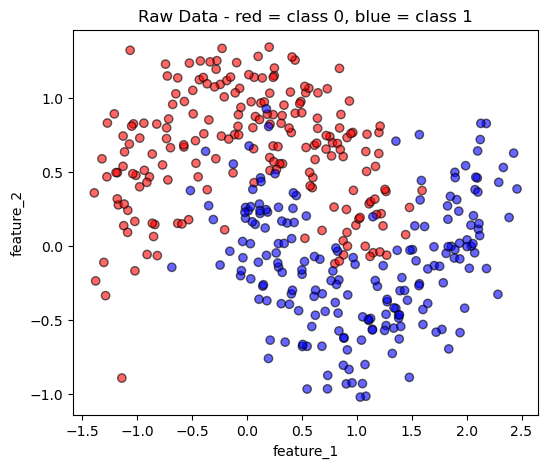

In [3]:
plt.figure(figsize=(6, 5))
colors = ["red" if l == 0 else "blue" for l in df["label"]]
plt.scatter(df["feature_1"], df["feature_2"], c=colors, alpha=0.6, edgecolor="k")
plt.title("Raw Data - red = class 0, blue = class 1")
plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.savefig("raw_data_plot.png")
plt.show()


In [14]:
X = df[["feature_1", "feature_2"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print()
print("train size:", len(X_train))
print("test size:", len(X_test))

#scaling the data, SVM is sensitive to feature scale so gotta do this (learned this the hard way after my first model performed poorly)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


train size: 300
test size: 100


In [5]:
print()
print("LINEAR KERNEL")
linear_svm = SVC(kernel="linear", C=1.0)
linear_svm.fit(X_train_scaled, y_train)
linear_preds = linear_svm.predict(X_test_scaled)
linear_acc = accuracy_score(y_test, linear_preds)
print("linear kernel accuracy:", linear_acc)


LINEAR KERNEL
linear kernel accuracy: 0.8


In [6]:
print()
print("=== RBF KERNEL ===")
rbf_svm = SVC(kernel="rbf", C=1.0, gamma="scale")
rbf_svm.fit(X_train_scaled, y_train)
rbf_preds = rbf_svm.predict(X_test_scaled)
rbf_acc = accuracy_score(y_test, rbf_preds)
print("rbf kernel accuracy:", rbf_acc)

# just double checking which one actually won
if rbf_acc > linear_acc:
    print("1")
else:
    print("0")


=== RBF KERNEL ===
rbf kernel accuracy: 0.91
1


In [8]:
print()
print("GRID SEARCH")
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [1, 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}

grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=1)
grid.fit(X_train_scaled, y_train)

print()
print("best params found:", grid.best_params_)
print("best cross val score:", grid.best_score_)

best_model = grid.best_estimator_
best_preds = best_model.predict(X_test_scaled)
best_acc = accuracy_score(y_test, best_preds)
print("test accuracy with tuned model:", best_acc)


GRID SEARCH
Fitting 5 folds for each of 16 candidates, totalling 80 fits

best params found: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
best cross val score: 0.9366666666666665
test accuracy with tuned model: 0.92



FINAL EVAL
[[47  3]
 [ 5 45]]

              precision    recall  f1-score   support

           0       0.90      0.94      0.92        50
           1       0.94      0.90      0.92        50

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



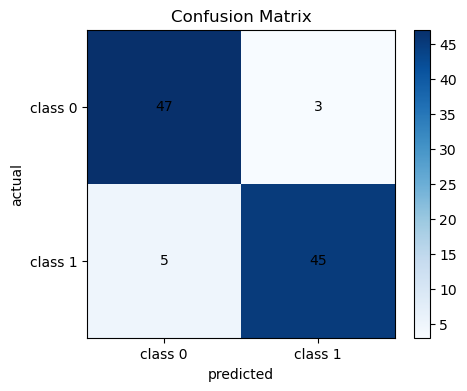

In [15]:
print()
print("FINAL EVAL")
print(confusion_matrix(y_test, best_preds))
print()
print(classification_report(y_test, best_preds))

#plot the confusion matrix cause raw numbers are hard to read
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["class 0", "class 1"])
plt.yticks([0, 1], ["class 0", "class 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i][j]), ha="center", va="center", color="black")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.savefig("confusion_matrix.png")
plt.show()


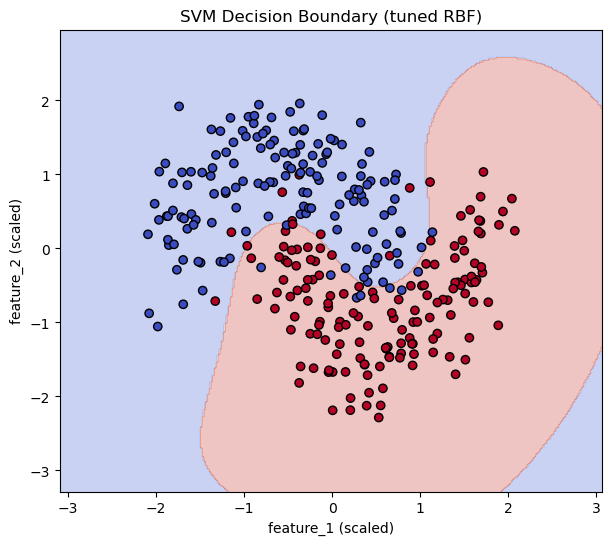


summary:
- linear kernel got 0.800 accuracy
- default rbf kernel got 0.910 accuracy
- tuned rbf kernel (after grid search) got 0.920 accuracy


In [17]:
def plot_decision_boundary(model, X_data, y_data, title):
    X_data = np.array(X_data)
    x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
    y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    #predict for every point on the grid so i can shade the regions
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap="coolwarm", edgecolor="k")
    plt.title(title)
    plt.xlabel("feature_1 (scaled)")
    plt.ylabel("feature_2 (scaled)")
    plt.savefig("decision_boundary.png")
    plt.show()

plot_decision_boundary(best_model, X_train_scaled, y_train.to_numpy(), "SVM Decision Boundary (tuned RBF)")


print()
print("summary:")
print(f"- linear kernel got {linear_acc:.3f} accuracy")
print(f"- default rbf kernel got {rbf_acc:.3f} accuracy")
print(f"- tuned rbf kernel (after grid search) got {best_acc:.3f} accuracy")
